# DEM & ACC EDA Notebook

This notebook performs exploratory data analysis (EDA) for a basin-level summary dataset derived from HydroSHEDS.

**Expected file:** `basin_dem_acc_stats.csv`

**Expected columns (at minimum):** `basin, dem_min, dem_max, dem_mean, dem_std, dem_median, acc_min, acc_max, acc_mean, acc_std, acc_median`

---

### Engineered features (computed in this notebook)  
- **`relief`** = `dem_max – dem_min` → vertical range of the basin (steepness).  
- **`elev_range_iqr_proxy`** = `dem_max – dem_median` → how extreme the highest peaks are compared to the typical elevation.  
- **`flow_density_proxy`** = `acc_mean ÷ relief` → normalized drainage concentration (how integrated the river network is, relative to steepness).  

---

👉 Use this framework to identify which basins lean more toward **flash floods**, **riverine floods**, or smaller localized events. 

In [1]:
# --- Setup ---
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pandas.plotting import scatter_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import geopandas as gpd
from shapely.errors import ShapelyDeprecationWarning
import warnings
warnings.filterwarnings("ignore", category=ShapelyDeprecationWarning)

## 1. Load data

In [2]:
# Path to your CSV. Change if needed.
CSV_PATH = "../../data/boundaries/processed/basin_dem_acc_stats.csv"

if not os.path.exists(CSV_PATH):
    print(f"⚠️ Could not find {CSV_PATH}. Please upload it to the same directory as this notebook or update CSV_PATH.")
else:
    print(f"Found data at: {os.path.abspath(CSV_PATH)}")

df = pd.read_csv(CSV_PATH) if os.path.exists(CSV_PATH) else pd.DataFrame()
df.head() if not df.empty else pd.DataFrame({"message": ["Upload your CSV and re-run this cell."]})


Found data at: /Users/liuq13/bhutan_climate_modeling/data/boundaries/processed/basin_dem_acc_stats.csv


,basin,dem_min,dem_max,dem_mean,dem_std,dem_median,acc_min,acc_max,acc_mean,acc_std,acc_median
0,Aiechhu,92.0,4160.0,1183.538707,699.525166,1091.0,1.0,3754703.0,210.078824,7825.328906,3.0
1,Merak_Sakteng,2690.0,4483.0,3882.785851,340.278285,3965.0,1.0,10252.0,65.099067,487.918880,3.0
2,Mangdechhu,109.0,7065.0,3230.588248,1302.878378,3287.0,1.0,979449.0,1070.502172,21801.824509,3.0
3,Jaldhakha,210.0,4577.0,1588.797296,1011.341252,1403.0,1.0,72476.0,199.115628,2573.336117,3.0
4,Amochhu,164.0,6689.0,3187.160344,1411.272228,3521.0,1.0,497461.0,894.656866,16011.294545,3.0


## 2. Quick overview

In [3]:
if df.empty:
    print("Dataframe is empty. Skip this section until data is loaded.")
else:
    print("Shape:", df.shape)
    print("\nColumns:", df.columns.tolist())
    print("\nDTypes:")
    print(df.dtypes)
    print("\nMissing values per column:")
    print(df.isna().sum())
    display(df.describe(include='all').T)


Shape: (10, 11)

Columns: ['basin', 'dem_min', 'dem_max', 'dem_mean', 'dem_std', 'dem_median', 'acc_min', 'acc_max', 'acc_mean', 'acc_std', 'acc_median']

DTypes:
basin          object
dem_min       float64
dem_max       float64
dem_mean      float64
dem_std       float64
dem_median    float64
acc_min       float64
acc_max       float64
acc_mean      float64
acc_std       float64
acc_median    float64
dtype: object

Missing values per column:
basin         0
dem_min       0
dem_max       0
dem_mean      0
dem_std       0
dem_median    0
acc_min       0
acc_max       0
acc_mean      0
acc_std       0
acc_median    0
dtype: int64


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
basin,10,10,Aiechhu,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dem_min,10.0,NaN,NaN,NaN,388.2,810.210096,90.0,95.25,113.0,198.5,2690.0
dem_max,10.0,NaN,NaN,NaN,5681.6,1329.927751,4160.0,4478.5,5633.0,6971.0,7127.0
dem_mean,10.0,NaN,NaN,NaN,2705.074135,986.648867,1183.538707,1751.476279,3168.106617,3230.049148,3882.785851
dem_std,10.0,NaN,NaN,NaN,1059.2056,350.122034,340.278285,940.051696,1046.488214,1379.90423,1417.195291
dem_median,10.0,NaN,NaN,NaN,2758.0,1145.613276,1091.0,1613.0,3193.5,3462.5,4292.0
acc_min,10.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
acc_max,10.0,NaN,NaN,NaN,1119181.5,1449880.92835,10252.0,108002.5,550083.5,1203148.5,3756205.0
acc_mean,10.0,NaN,NaN,NaN,762.786711,624.300756,65.099067,236.04779,651.810198,1075.110325,1944.081318
acc_std,10.0,NaN,NaN,NaN,16509.837865,16515.263984,487.91888,4818.724134,11918.311726,21348.534754,52827.403693


## 3. Ensure numeric types
If some numeric columns were read as strings, this coerces them.

In [4]:
if not df.empty:
    # identify numeric columns by name patterns; adjust if your names differ
    numeric_like = [c for c in df.columns if c != "basin"]
    for c in numeric_like:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    print("Coerced potential numeric columns to numeric (with NaN for non-convertible entries).")
    print(df[numeric_like].dtypes)


Coerced potential numeric columns to numeric (with NaN for non-convertible entries).
dem_min       float64
dem_max       float64
dem_mean      float64
dem_std       float64
dem_median    float64
acc_min       float64
acc_max       float64
acc_mean      float64
acc_std       float64
acc_median    float64
dtype: object


## 4. Feature engineering

In [5]:
if not df.empty:
    df['relief'] = df['dem_max'] - df['dem_min']
    df['elev_range_iqr_proxy'] = df['dem_max'] - df['dem_median']  # simple spread proxy
    # Flow density proxy: acc_mean / relief (avoid div by zero)
    df['flow_density_proxy'] = df['acc_mean'] / (df['relief'].replace(0, np.nan))
    display(df[['basin','relief','elev_range_iqr_proxy','flow_density_proxy']])


,basin,relief,elev_range_iqr_proxy,flow_density_proxy
0,Aiechhu,4068.0,3069.0,0.051642
1,Merak_Sakteng,1793.0,518.0,0.036307
2,Mangdechhu,6956.0,3778.0,0.153896
3,Jaldhakha,4367.0,3174.0,0.045596
4,Amochhu,6525.0,3168.0,0.137112
5,Wangchhu,6572.0,3419.0,0.163823
6,Drangmechhu,7037.0,2835.0,0.276266
7,Punatsangchhu,6993.0,3970.0,0.206602
8,Nyera_Amari,4363.0,3071.0,0.071958
9,Jomori,4260.0,2234.0,0.096001


## Engineered Features  

### 1. `relief`  
- **Formula:** `dem_max – dem_min`  
- **Meaning:** Vertical range of elevation in a basin (meters).  
- **Logic:** High relief = steeper terrain, stronger gravitational force on water, faster runoff → more prone to **flash floods**.  

---

### 2. `elev_range_iqr_proxy`  
- **Formula:** `dem_max – dem_median`  
- **Meaning:** How extreme the highest peaks are compared to the “typical” elevation.  
- **Logic:** Large values suggest high headwaters above the main valley → can indicate potential for **glacier- or lake-fed flooding (GLOF)** because water stored at high elevations can suddenly discharge downslope.  

---

### 3. `flow_density_proxy`  
- **Formula:** `acc_mean ÷ relief`  
- **Meaning:** Average flow accumulation normalized by elevation range.  
- **Logic:**  
  - High values → drainage network is dense and well-integrated for the terrain → favors **riverine flooding** (large downstream flows).  
  - Low values → less integrated drainage for the same relief → water concentrates locally in steep valleys → favors **flash floods**.  

 


## 5. Scatter plot: Relief vs Flow Density Proxy

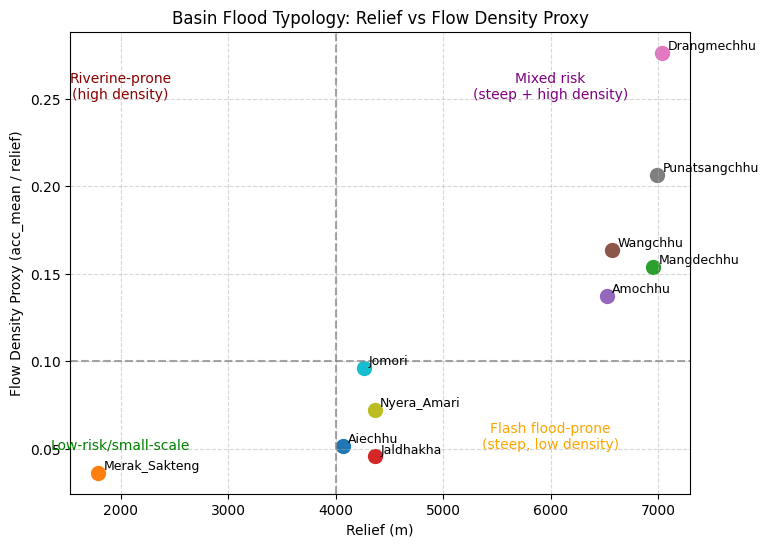

In [6]:
plt.figure(figsize=(8,6))

for i, row in df.iterrows():
    plt.scatter(row['relief'], row['flow_density_proxy'], s=100)
    plt.text(row['relief']+50, row['flow_density_proxy']+0.002, 
             row['basin'], fontsize=9)

plt.xlabel("Relief (m)")
plt.ylabel("Flow Density Proxy (acc_mean / relief)")
plt.title("Basin Flood Typology: Relief vs Flow Density Proxy")

# Add interpretive zones (rough)
plt.axhline(0.1, color="grey", linestyle="--", alpha=0.7)
plt.axvline(4000, color="grey", linestyle="--", alpha=0.7)
plt.text(2000, 0.25, "Riverine-prone\n(high density)", ha="center", fontsize=10, color="darkred")
plt.text(2000, 0.05, "Low-risk/small-scale", ha="center", fontsize=10, color="green")
plt.text(6000, 0.05, "Flash flood-prone\n(steep, low density)", ha="center", fontsize=10, color="orange")
plt.text(6000, 0.25, "Mixed risk\n(steep + high density)", ha="center", fontsize=10, color="purple")

plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


## Interpreting the 2×2 Plot  

The scatter plot places **Relief (x-axis)** against **Flow Density Proxy (y-axis)**:  

- **X-axis (Relief):**  
  - Low → flatter terrain.  
  - High → steep, mountainous terrain.  

- **Y-axis (Flow Density Proxy):**  
  - Low → weakly integrated drainage (local runoff dominates).  
  - High → strongly integrated drainage (large rivers dominate).  

This creates four interpretive zones:  

|                | **Low Flow Density Proxy** | **High Flow Density Proxy** |
|----------------|-----------------------------|-----------------------------|
| **Low Relief** | **Small-scale / localized floods** → flatter basins, weak drainage (e.g., Merak_Sakteng). | Rare case, could mean concentrated drainage in relatively flat basin. |
| **High Relief** | **Flash flood-prone** → steep slopes, but drainage not well integrated (e.g., Jaldhakha, Aiechhu). | **Riverine / mixed floods** → steep slopes *and* strong drainage integration, combining flashiness upstream with large downstream floods (e.g., Drangmechhu, Punatsangchhu). |

---

👉 **Takeaway:**  
- Relief tells you about **how fast water moves** (steepness).  
- Flow density proxy tells you about **how connected the drainage is** (extent of river network).  
- Putting them together distinguishes between **flash floods** (steep but fragmented) and **riverine floods** (steep + well integrated). 

## 6. Choropleth Maps: Spatial Patterns of Relief and Flow Density Proxy  

In this section, we map the engineered features back onto basin geometries.  
- **Relief map** highlights which basins are steep vs relatively flat.  
- **Flow Density Proxy map** highlights how concentrated drainage networks are across basins.  

These continuous choropleths allow quick visual identification of areas that may lean more toward **flash-flood susceptibility** (high relief, low density) or **riverine flood susceptibility** (high relief, high density).


In [7]:
# --- Load basin shapefile ---
basins_gdf = gpd.read_file("../../data/boundaries/basins/Basin boundary.shp")
basins_gdf

,basin,path,area_ha,area_sqkm,SHAPE__Len,SHAPE__Are,geometry
0,Aiechhu,E:\2024-2025\Basin_boundaries\Aiechhu.shp,1.963906e+05,1963.905886,3.370194e+05,2.481073e+09,"POLYGON ((10058028.821 3151062.425, 10058067.6..."
1,Merak_Sakteng,E:\2024-2025\Basin_boundaries\Merak-Sakteng.shp,1.388107e+04,138.810677,7.676774e+04,1.763939e+08,"POLYGON ((10245694.293 3155611.158, 10245655.4..."
2,Mangdechhu,E:\2024-2025\Basin_boundaries\Tb_basins.shp,7.436605e+05,7436.605311,5.247929e+05,9.488740e+09,"POLYGON ((10104749.232 3241419.811, 10104770.6..."
3,Jaldhakha,E:\2024-2025\Basin_boundaries\Tb_basins.shp,1.038943e+05,1038.942931,2.520154e+05,1.314962e+09,"POLYGON ((9901165.919 3115267.068, 9901469.152..."
4,Amochhu,E:\2024-2025\Basin_boundaries\Tb_basins.shp,3.929619e+05,3929.619367,4.884296e+05,4.999591e+09,"POLYGON ((9941137.001 3103799.993, 9940925.883..."
5,Wangchhu,E:\2024-2025\Basin_boundaries\Tb_basins.shp,4.608337e+05,4608.336971,4.806525e+05,5.864101e+09,"POLYGON ((9963497.782 3221300.499, 9963619.647..."
6,Drangmechhu,E:\2024-2025\Basin_boundaries\Tb_basins.shp,2.109827e+06,21098.266822,1.062589e+06,2.707480e+10,"POLYGON ((10125220.539 3097000.13, 10124839.34..."
7,Punatsangchhu,E:\2024-2025\Basin_boundaries\Tb_basins.shp,9.765747e+05,9765.747380,7.053781e+05,1.247491e+10,"POLYGON ((9994788.454 3086639.396, 9994098.961..."
8,Nyera_Amari,E:\2024-2025\Basin_boundaries\Nyera Amari.shp,2.262234e+05,2262.233550,4.147678e+05,2.858317e+09,"POLYGON ((10252730.763 3108653.318, 10252803.3..."
9,Jomori,E:\2024-2025\Basin_boundaries\Jomori.shp,7.503194e+04,750.319391,1.833266e+05,9.500465e+08,"POLYGON ((10239085.718 3162037.801, 10239283.5..."


In [8]:
# Merge with your basin EDA dataframe
# Assumes your `df` has a "basin" column matching shapefile attribute (adjust as needed)
g = basins_gdf.merge(df[['basin','relief','flow_density_proxy']], on='basin')

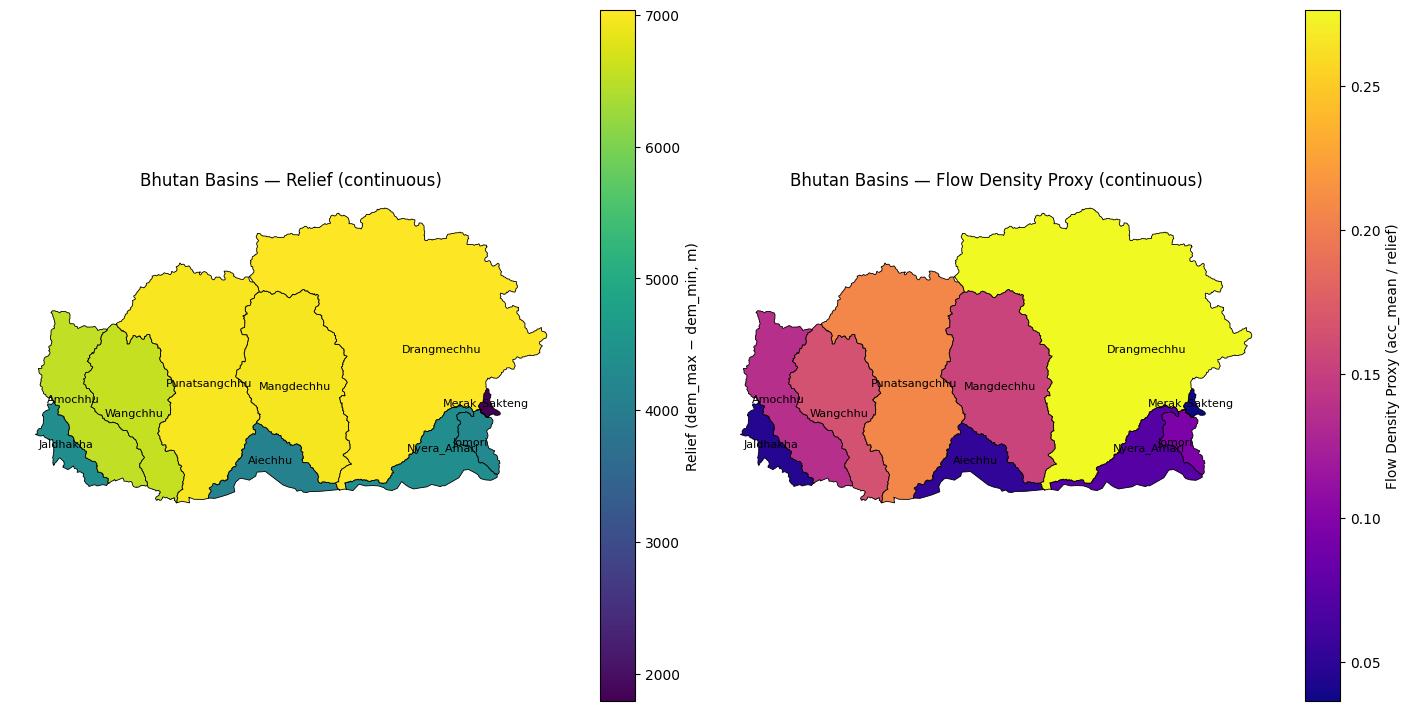

In [9]:
# Assumes you already have:
# g  -> a GeoDataFrame with columns: ['basin', 'geometry', 'relief', 'flow_density_proxy', ...]
# CRS can be anything; we won't reproject unless you need to.

# --- Safety: coerce to numeric in case they came in as objects ---
g = g.copy()
for col in ["relief", "flow_density_proxy"]:
    g[col] = pd.to_numeric(g[col], errors="coerce")

# --- Label points placed inside each polygon (works better than centroids on concave shapes) ---
pts = g.geometry.representative_point()
g["lab_x"] = pts.x
g["lab_y"] = pts.y

# --- Side-by-side continuous maps (no binning) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 7), constrained_layout=True)

# Map 1: Relief
g.plot(
    column="relief",
    cmap="viridis",
    linewidth=0.6,
    edgecolor="black",
    legend=True,
    legend_kwds={"label": "Relief (dem_max − dem_min, m)"},
    ax=axes[0]
)
for _, row in g.iterrows():
    axes[0].text(row["lab_x"], row["lab_y"], str(row["basin"]), fontsize=8, ha="center", va="center")
axes[0].set_title("Bhutan Basins — Relief (continuous)")
axes[0].axis("off")

# Map 2: Flow Density Proxy
g.plot(
    column="flow_density_proxy",
    cmap="plasma",   # choose any continuous cmap you like
    linewidth=0.6,
    edgecolor="black",
    legend=True,
    legend_kwds={"label": "Flow Density Proxy (acc_mean / relief)"},
    ax=axes[1]
)
for _, row in g.iterrows():
    axes[1].text(row["lab_x"], row["lab_y"], str(row["basin"]), fontsize=8, ha="center", va="center")
axes[1].set_title("Bhutan Basins — Flow Density Proxy (continuous)")
axes[1].axis("off")

plt.show()